# Medical Insurance Cost Prediction using Multiple Linear Regression

**Objective:** Build a Multiple Linear Regression model to predict medical insurance charges based on personal and health-related information.

**Dataset:** [Medical Cost Personal Insurance Dataset (Kaggle)](https://www.kaggle.com/datasets/mirichoi0218/insurance)


## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline
sns.set_style("whitegrid")

## Task 1: Data Understanding (2 Marks)

Load the dataset and explore its structure, identifying numerical features, categorical features, and the target variable.

In [2]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
print("Shape of dataset:", df.shape)
print("\nColumn info:")
df.info()

Shape of dataset: (1338, 7)

Column info:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
numerical_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']
target_variable = 'charges'

print("Numerical features   :", numerical_features)
print("Categorical features :", categorical_features)
print("Target variable      :", target_variable)

Numerical features   : ['age', 'bmi', 'children']
Categorical features : ['sex', 'smoker', 'region']
Target variable      : charges


### Quick Exploratory Visualization
A look at how charges are distributed and how they relate to smoking status (expected to be a strong predictor).

/tmp/ipykernel_579/2770400364.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='charges', ax=axes[1], palette='Set2')


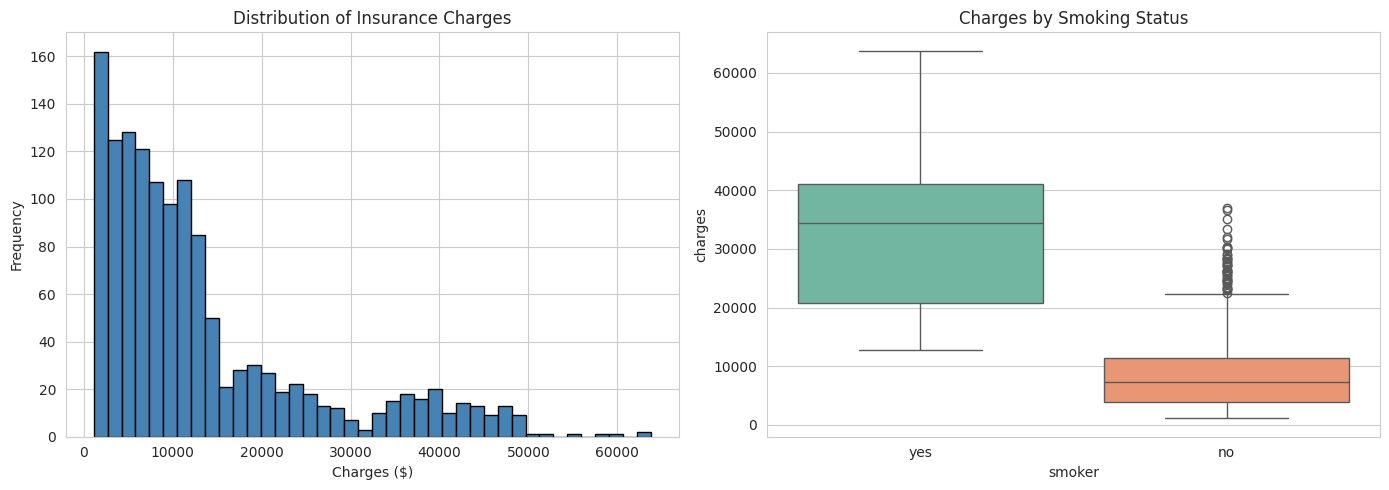

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['charges'], bins=40, color='steelblue', edgecolor='k')
axes[0].set_title('Distribution of Insurance Charges')
axes[0].set_xlabel('Charges ($)')
axes[0].set_ylabel('Frequency')

sns.boxplot(data=df, x='smoker', y='charges', ax=axes[1], palette='Set2')
axes[1].set_title('Charges by Smoking Status')

plt.tight_layout()
plt.show()

## Task 2: Data Preprocessing (2 Marks)

- Check for missing values
- Encode categorical variables (`sex`, `smoker`, `region`)
- Split into 80% training / 20% testing

In [7]:
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
df_encoded = df.copy()

# Label encoding for binary categorical variables
df_encoded['sex'] = df_encoded['sex'].map({'male': 0, 'female': 1})
df_encoded['smoker'] = df_encoded['smoker'].map({'no': 0, 'yes': 1})

# One-hot encoding for region (drop_first avoids the dummy variable trap)
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)
region_cols = [c for c in df_encoded.columns if c.startswith('region_')]
df_encoded[region_cols] = df_encoded[region_cols].astype(int)

df_encoded.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,1
1,18,0,33.770,1,0,1725.55230,0,1,0
2,28,0,33.000,3,0,4449.46200,0,1,0
3,33,0,22.705,0,0,21984.47061,1,0,0
4,32,0,28.880,0,0,3866.85520,1,0,0


In [9]:
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} records")
print(f"Testing set size : {X_test.shape[0]} records")

Training set size: 1070 records
Testing set size : 268 records


## Task 3: Model Development (3 Marks)

Train a Multiple Linear Regression model using: `age`, `sex`, `bmi`, `children`, `smoker`, `region` to predict `charges`.

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Intercept:", model.intercept_)
print("\nCoefficients:")
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coef_df.sort_values('Coefficient', ascending=False)

Intercept: -11949.810741967713

Coefficients:


,Feature,Coefficient
4,smoker,23651.128856
3,children,425.278784
2,bmi,337.092552
0,age,256.975706
1,sex,18.591692
5,region_northwest,-370.677326
6,region_southeast,-657.864297
7,region_southwest,-809.799354


In [11]:
comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
comparison.head(10)

,Actual,Predicted
0,9095.06825,8969.550274
1,5272.17580,7068.747443
2,29330.98315,36858.410912
3,9301.89355,9454.678501
4,33750.29180,26973.173457
5,4536.25900,10864.113164
6,2117.33885,170.280841
7,14210.53595,16903.450287
8,3732.62510,1092.430936
9,10264.44210,11218.343184


## Task 4: Model Evaluation (2 Marks)

Evaluate using MAE, MSE, R2 Score, and visualize Actual vs Predicted charges.

In [12]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE) : {mae:,.2f}")
print(f"Mean Squared Error  (MSE) : {mse:,.2f}")
print(f"Root Mean Squared Error   : {rmse:,.2f}")
print(f"R2 Score                  : {r2:.4f}")

Mean Absolute Error (MAE) : 4,181.19
Mean Squared Error  (MSE) : 33,596,915.85
Root Mean Squared Error   : 5,796.28
R2 Score                  : 0.7836


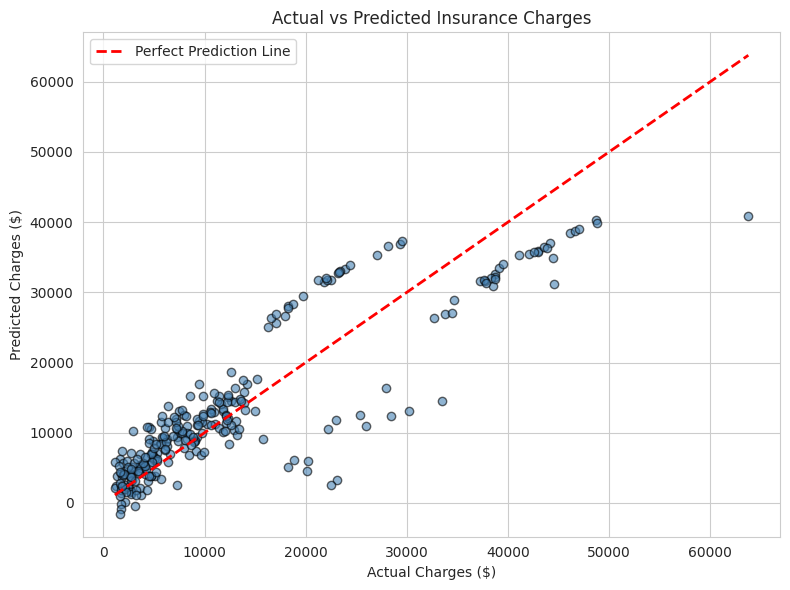

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.title('Actual vs Predicted Insurance Charges')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

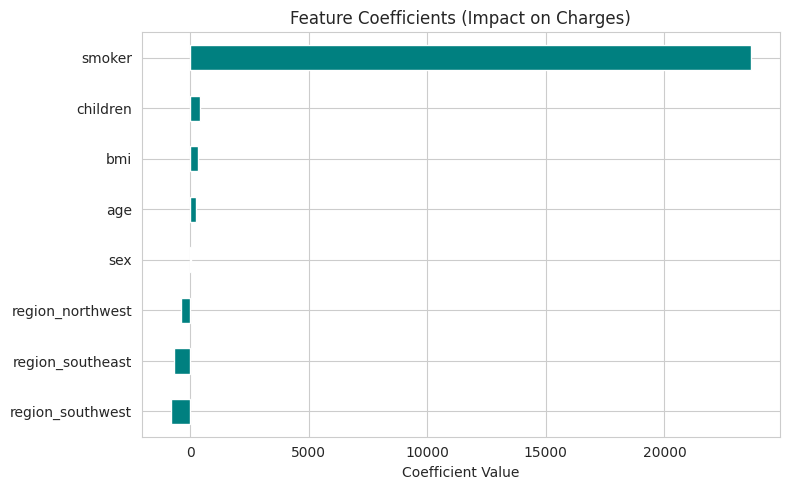

In [14]:
plt.figure(figsize=(8, 5))
coef_series = pd.Series(model.coef_, index=X.columns).sort_values()
coef_series.plot(kind='barh', color='teal')
plt.xlabel('Coefficient Value')
plt.title('Feature Coefficients (Impact on Charges)')
plt.tight_layout()
plt.savefig('feature_coefficients.png', dpi=150)
plt.show()

### Observations

1. **Smoking status is the dominant predictor** — the `smoker` coefficient (~23,650) dwarfs every other feature, meaning a smoker's predicted charges are tens of thousands of dollars higher than a non-smoker's, all else equal.
2. **Age and BMI both increase predicted charges**, consistent with the intuition that older age and higher BMI are associated with greater medical risk and cost.
3. **The model explains roughly 78% of the variance in charges (R² ≈ 0.78)**, which is a reasonably strong fit for a linear model, but the scatter plot shows the model under-predicts for some high-charge outliers — likely smokers with additional risk factors, where the true relationship is non-linear (e.g., smoking combined with high BMI compounds cost more than additively).

## Task 5: Conclusion (1 Mark)

This project used Multiple Linear Regression to predict medical insurance charges from six features: age, sex, BMI, number of children, smoking status, and region. After encoding categorical variables and splitting the data 80/20, the trained model achieved an R² score of approximately 0.78 on the test set, meaning it explains about 78% of the variability in insurance charges. The most important finding is that **smoking status** is by far the strongest driver of higher charges, followed by **age** and **BMI**, while **sex** and **region** have comparatively minor effects. These results align with real-world medical risk factors, where smoking and obesity are well-known contributors to higher healthcare costs.

A key limitation of Linear Regression here is its assumption of a **linear, additive relationship** between features and the target. In reality, factors like smoking and BMI likely interact (a smoker with high BMI may incur disproportionately higher costs than the sum of each factor's individual effect), and charges may grow non-linearly with age. Because plain linear regression cannot capture these interactions or non-linear patterns, it under-predicts costs for some high-risk individuals. Techniques such as polynomial regression, interaction terms, or ensemble methods (e.g., Random Forest, Gradient Boosting) could likely improve predictive accuracy.